# MSFT Next-Day Direction Predictor — Iteration 4: ARIMAX

**Author:** Lucan den Dekker  
**Project:** ADSAI Group 15 Block D Capstone  
**Date:** 2026-06-03  
**Pre-trained model:** ARIMAX (ARIMA with eXogenous variables: SPY, VIX, gold, oil)

---

**Improvements over Iteration 3**

| Change | Reason |
|---|---|
| ARIMAX replaces direct binary classifier | ARIMA + macro signals (SPY, VIX, gold, oil) as exogenous inputs |
| `pmdarima.auto_arima` for optimal order | Automatic AIC-minimising search over ARIMAX(p,d,q) |
| Walk-forward one-step-ahead evaluation | Each forecast uses all history up to that day — zero lookahead bias |
| Trained on last 2 years only | Keeps coefficients calibrated on the current market regime |
| SPY / VIX / gold / oil as exogenous | Macro signals available at end-of-day, no lookahead |
| Threshold sweep (Section 5b) | Finds the confidence threshold that maximises precision vs coverage |

| Section | Content |
|---|---|
| 0 | Imports and Setup |
| 1 | Load Data |
| 2 | Feature Engineering (for target labels) |
| 3 | Train/Test Split + Exogenous Variables |
| 4 | Baseline Model |
| 5 | ARIMAX: Order Selection, Walk-Forward Forecast, Direction Signal |
| 5b | Threshold Sweep: Precision vs Coverage |
| 6 | Model Comparison (ARIMAX vs Baseline) |
| 7 | Error Analysis |
| 8 | Business Value Interpretation |

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib pmdarima statsmodels

Note: you may need to restart the kernel to use updated packages.


---
## Section 0 — Imports and Setup

`pmdarima` provides `auto_arima` for automatic ARIMA(p,d,q) order selection and an
online-updatable model for walk-forward forecasting via `.update()`.

`RANDOM_SEED = 42` is applied where applicable. `NEUTRAL_THRESHOLD = 0.2` matches
it3 for comparable direction labels.

In [2]:
# Standard library
import warnings
import logging
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Scikit-learn (metrics + baseline)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# ARIMA
import pmdarima as pm

# Persistence
import joblib

# Reproducibility
RANDOM_SEED: int = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("msft_modelling")

# Plot style
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("seaborn-darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13

NEUTRAL_THRESHOLD: float = 0.2


def find_project_root(marker: str = "README.md") -> Path:
    """Walk up the directory tree until a marker file is found."""
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    logger.warning("Project root not found; falling back to cwd.")
    return current


PROJECT_ROOT = find_project_root()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "msft_merged.csv"
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "msft-forecaster" / "data" / "processed" / "msft_merged.csv"

MODELS_DIR = PROJECT_ROOT / "models" / "lucan"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Project root : %s", PROJECT_ROOT)
logger.info("Data path    : %s", DATA_PATH)
logger.info("Models dir   : %s", MODELS_DIR)

2026-06-03 14:09:38 | INFO | Project root : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15
2026-06-03 14:09:38 | INFO | Data path    : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\data\processed\msft_merged.csv
2026-06-03 14:09:38 | INFO | Models dir   : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan


---
## Section 1 — Load Data

Full 2015–2026 dataset. ARIMA operates on the raw `Close` price series so `df_raw`
is retained alongside the feature-engineered `df` (used only for target labels).

In [3]:
def load_data(path: Path) -> pd.DataFrame:
    """Load the MSFT merged CSV and return a date-indexed DataFrame.

    Parameters
    ----------
    path : Path
        Absolute path to the CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame with a DatetimeIndex sorted ascending.

    Raises
    ------
    FileNotFoundError
        If the CSV file does not exist.
    ValueError
        If no date column is detected.
    """
    if not path.exists():
        raise FileNotFoundError(f"Data file not found: {path}")

    df = pd.read_csv(path)

    date_col = next(
        (c for c in df.columns if c.lower() in ("date", "datetime", "timestamp")),
        None,
    )
    if date_col is None:
        raise ValueError(f"No date column found. Columns: {list(df.columns)}")

    df[date_col] = pd.to_datetime(df[date_col])
    df.set_index(date_col, inplace=True)
    df.index.name = "Date"
    df.sort_index(inplace=True)
    return df


df_raw = load_data(DATA_PATH)
logger.info(
    "Loaded: shape=%s | %s to %s",
    df_raw.shape,
    df_raw.index.min().date(),
    df_raw.index.max().date(),
)

missing = int(df_raw.isnull().sum().sum())
if missing > 0:
    logger.warning("%d missing values found; dropping affected rows.", missing)
    df_raw = df_raw.dropna()
else:
    logger.info("No missing values found.")

logger.info("Using full dataset: %d rows", len(df_raw))
print(df_raw.head())

2026-06-03 14:09:38 | INFO | Loaded: shape=(2818, 9) | 2015-02-17 to 2026-04-30
2026-06-03 14:09:38 | INFO | No missing values found.
2026-06-03 14:09:38 | INFO | Using full dataset: 2818 rows


             Open     High    Low   Close      Volume   gold_close  oil_close  \
Date                                                                            
2015-02-17  43.97  44.0000  43.19  43.580  33695149.0  1208.099976  53.529999   
2015-02-18  43.63  43.7000  43.39  43.530  27111657.0  1199.699951  52.139999   
2015-02-19  43.18  43.5263  43.05  43.500  27556420.0  1207.099976  51.160000   
2015-02-20  43.51  43.8800  43.29  43.855  29721133.0  1204.400024  50.340000   
2015-02-23  43.70  44.1900  43.65  44.150  32518754.0  1200.300049  49.450001   

              vix   spy_close  
Date                           
2015-02-17  15.80  174.000732  
2015-02-18  15.45  174.017288  
2015-02-19  15.29  173.893082  
2015-02-20  14.30  174.936493  
2015-02-23  14.56  174.911667  


---
## Section 2 — Feature Engineering (Target Labels)

`engineer_features` computes binary direction labels (`target`) used to evaluate
ARIMA's forecasts. Same ±0.2 % neutral threshold as it3.

In [4]:
def _detect_column(df: pd.DataFrame, candidates: list) -> str:
    """Return the first column name matching any candidate (case-insensitive)."""
    col_lower = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in col_lower:
            return col_lower[name]
    raise KeyError(f"None of {candidates} found in columns: {list(df.columns)}")


def engineer_features(df: pd.DataFrame, threshold: float = NEUTRAL_THRESHOLD) -> pd.DataFrame:
    """Compute binary direction target labels from MSFT close prices.

    Only the `target` column is strictly required for Prophet evaluation.
    The neutral zone (|return| < threshold) is excluded — consistent with it1-3.

    Parameters
    ----------
    df : pd.DataFrame
        Raw merged MSFT dataframe with a DatetimeIndex.
    threshold : float
        Minimum absolute next-day return (%) to label as UP or DOWN.

    Returns
    -------
    pd.DataFrame
        DataFrame with a binary integer 'target' column; neutral days dropped.
    """
    df = df.copy()
    close = df[_detect_column(df, ["close", "msft_close", "adj close", "adj_close"])]

    next_day_return = (close.shift(-1) - close) / close * 100
    df["target"] = np.select(
        [next_day_return > threshold, next_day_return < -threshold],
        [1, 0],
        default=np.nan,
    )
    df = df.dropna(subset=["target"])
    df["target"] = df["target"].astype(int)
    df = df.dropna()

    class_counts = df["target"].value_counts().sort_index()
    logger.info(
        "Threshold=%.1f%%  DOWN(0): %d | UP(1): %d  | total: %d",
        threshold,
        class_counts.get(0, 0),
        class_counts.get(1, 0),
        len(df),
    )
    return df


df = engineer_features(df_raw)
close_col = _detect_column(df_raw, ["close", "msft_close", "adj close", "adj_close"])

2026-06-03 14:09:38 | INFO | Threshold=0.2%  DOWN(0): 1089 | UP(1): 1278  | total: 2367


---
## Section 3 — Train/Test Split + Exogenous Variables

Two splits plus exogenous variable matrices:

1. **Feature split** (`df_train` / `df_test`): binary target labels, same 80/20 as it1–3.
2. **ARIMAX close series** — last 2 years before test boundary.
3. **Exogenous variables** — lagged 1 day so they are known at prediction time:

| Variable | Source | Why useful |
|---|---|---|
| `lag_spy_return` | SPY pct_change (t-1) | Broad market direction — MSFT correlates ~0.7 with S&P 500 |
| `lag_vix` | VIX (t-1) | Market fear gauge — high VIX often precedes DOWN days |
| `lag_gold_return` | gold_close pct_change (t-1) | Risk-off signal — gold rises when equities fall |
| `lag_oil_return` | oil_close pct_change (t-1) | Macro risk-on/risk-off proxy |

**Why lagged?** ARIMAX requires X[t+1] to predict y[t+1]. By defining X[t] as yesterday's
macro values, X[t+1] = today's actual values — which are fully known after market close,
ensuring zero lookahead bias.

In [5]:
# ── Feature split (for target labels) ───────────────────────────────────────
split_idx = int(len(df) * 0.80)
df_train  = df.iloc[:split_idx]
df_test   = df.iloc[split_idx:]

logger.info("Feature train: %d rows | %s to %s",
            len(df_train), df_train.index.min().date(), df_train.index.max().date())
logger.info("Feature test : %d rows | %s to %s",
            len(df_test), df_test.index.min().date(), df_test.index.max().date())

y_test = df_test["target"]

# ── ARIMAX close series — last 2 years only ──────────────────────────────────
TRAIN_YEARS     = 2
test_start_date = df_test.index.min()
train_cutoff    = test_start_date - pd.DateOffset(years=TRAIN_YEARS)

close_train = df_raw.loc[
    (df_raw.index >= train_cutoff) & (df_raw.index < test_start_date), close_col,
].dropna()
close_test = df_raw.loc[df_raw.index >= test_start_date, close_col].dropna()

# ── Exogenous variables (lagged 1 day — no lookahead) ────────────────────────
# lagged_exog[t] = yesterday's macro values → used in ARIMAX model equation y[t]
# current_exog[t] = today's macro values   → passed as X[t+1] when predicting y[t+1]
spy_col  = _detect_column(df_raw, ["spy_close", "spy"])
vix_col  = _detect_column(df_raw, ["vix"])
gold_col = _detect_column(df_raw, ["gold_close", "gold"])
oil_col  = _detect_column(df_raw, ["oil_close", "oil"])

lagged_exog = pd.DataFrame({
    "lag_spy_return":  df_raw[spy_col].pct_change().shift(1) * 100,
    "lag_vix":         df_raw[vix_col].shift(1),
    "lag_gold_return": df_raw[gold_col].pct_change().shift(1) * 100,
    "lag_oil_return":  df_raw[oil_col].pct_change().shift(1) * 100,
}, index=df_raw.index).dropna()

current_exog = pd.DataFrame({
    "lag_spy_return":  df_raw[spy_col].pct_change() * 100,
    "lag_vix":         df_raw[vix_col],
    "lag_gold_return": df_raw[gold_col].pct_change() * 100,
    "lag_oil_return":  df_raw[oil_col].pct_change() * 100,
}, index=df_raw.index).dropna()

# Align training data with exogenous (some rows dropped by pct_change + shift)
train_common   = close_train.index.intersection(lagged_exog.index)
close_train_x  = close_train.loc[train_common]
X_train        = lagged_exog.loc[train_common].values

logger.info("ARIMAX train : %d rows | %s to %s  (last %d yr)",
            len(close_train_x), close_train_x.index.min().date(),
            close_train_x.index.max().date(), TRAIN_YEARS)
logger.info("ARIMAX test  : %d rows | %s to %s",
            len(close_test), close_test.index.min().date(), close_test.index.max().date())
logger.info("Exogenous features: %s", list(lagged_exog.columns))

print(f"Feature test  : {len(df_test)} rows")
print(f"ARIMAX train  : {len(close_train_x)} rows")
print(f"ARIMAX test   : {len(close_test)} rows")
print(f"Exog columns  : {list(lagged_exog.columns)}")

2026-06-03 14:09:38 | INFO | Feature train: 1893 rows | 2015-02-19 to 2024-01-25
2026-06-03 14:09:38 | INFO | Feature test : 474 rows | 2024-01-26 to 2026-04-29
2026-06-03 14:09:38 | INFO | ARIMAX train : 502 rows | 2022-01-26 to 2024-01-25  (last 2 yr)
2026-06-03 14:09:38 | INFO | ARIMAX test  : 567 rows | 2024-01-26 to 2026-04-30
2026-06-03 14:09:38 | INFO | Exogenous features: ['lag_spy_return', 'lag_vix', 'lag_gold_return', 'lag_oil_return']


Feature test  : 474 rows
ARIMAX train  : 502 rows
ARIMAX test   : 567 rows
Exog columns  : ['lag_spy_return', 'lag_vix', 'lag_gold_return', 'lag_oil_return']


---
## Section 4 — Baseline Model (Majority-Class Classifier)

The majority-class baseline always predicts the most frequent class (UP, due to
MSFT's long-term upward trend). It establishes the performance floor.

In [6]:
def evaluate_model(y_true, y_pred, model_name: str) -> dict:
    """Compute weighted classification metrics and return as a results dict.

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.
    y_pred : array-like
        Predicted labels.
    model_name : str
        Human-readable identifier.

    Returns
    -------
    dict
        Keys: 'Model', 'Accuracy', 'Precision', 'Recall', 'F1'.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    logger.info(
        "%s  Acc=%.4f  Prec=%.4f  Rec=%.4f  F1=%.4f",
        model_name, acc, prec, rec, f1,
    )
    return {
        "Model":     model_name,
        "Accuracy":  round(acc,  4),
        "Precision": round(prec, 4),
        "Recall":    round(rec,  4),
        "F1":        round(f1,   4),
    }


def plot_confusion_matrix(y_true, y_pred, model_name: str) -> None:
    """Plot a seaborn heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True, fmt="d", cmap="Blues",
        xticklabels=["DOWN (0)", "UP (1)"],
        yticklabels=["DOWN (0)", "UP (1)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


# Majority-class baseline: features don't affect DummyClassifier, use placeholder
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(np.zeros((len(y_test), 1)), y_test)
y_pred_dummy = dummy.predict(np.zeros((len(y_test), 1)))

baseline_metrics = evaluate_model(y_test, y_pred_dummy, "Baseline (Majority Class)")
print(classification_report(y_test, y_pred_dummy, target_names=["DOWN", "UP"]))

2026-06-03 14:09:38 | INFO | Baseline (Majority Class)  Acc=0.5316  Prec=0.2826  Rec=0.5316  F1=0.3691


              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00       222
          UP       0.53      1.00      0.69       252

    accuracy                           0.53       474
   macro avg       0.27      0.50      0.35       474
weighted avg       0.28      0.53      0.37       474



---
## Section 5 — ARIMAX: Order Selection, Walk-Forward Forecast, Direction Signal

**ARIMAX** extends ARIMA by adding exogenous variables to the model equation:

```
y[t] = ARIMA(y[t-1],...) + β₁·lag_spy[t] + β₂·lag_vix[t] + β₃·lag_gold[t] + β₄·lag_oil[t] + ε[t]
```

The β coefficients measure how much each macro signal shifts the expected price.

### Walk-Forward with Exogenous Variables

For each test step i (current date `d`):
1. **Predict**: `model.predict(n_periods=1, X=current_exog[d])` — passes today's
   macro values as X[t+1] (= the lagged input for the next step). No lookahead.
2. **Update**: `model.update([actual_close], X=lagged_exog[d])` — tells the model
   what the lagged exogenous WAS for this observation.

If exogenous data is missing for a date, the model falls back to pure ARIMA.

2026-06-03 14:09:38 | INFO | Running auto_arima (ARIMAX) on 502 training observations ...
2026-06-03 14:09:39 | INFO | auto_arima selected ARIMAX(0, 1, 0)  AIC=3101.12
2026-06-03 14:09:39 | INFO | Walk-forward over 567 test observations ...


Selected order: ARIMAX(0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  502
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1545.559
Date:                Wed, 03 Jun 2026   AIC                           3101.118
Time:                        14:09:39   BIC                           3122.201
Sample:                             0   HQIC                          3109.391
                                - 502                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1529      0.174      0.877      0.381      -0.189       0.495
x2             0.2510      0.196      1.279      0.201      -0.134       0.636
x3             0.068

2026-06-03 14:10:28 | INFO | Walk-forward complete. 567 forecasts generated.
2026-06-03 14:10:28 | INFO | ARIMAX model saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\arimax_lucan_it4.pkl
2026-06-03 14:10:28 | INFO | ARIMAX direction: 396 predictions, 78 neutral (excluded)
2026-06-03 14:10:28 | INFO | ARIMAX Direction Signal  Acc=0.4975  Prec=0.5016  Rec=0.4975  F1=0.4976


              precision    recall  f1-score   support

        DOWN       0.47      0.53      0.50       185
          UP       0.53      0.47      0.50       211

    accuracy                           0.50       396
   macro avg       0.50      0.50      0.50       396
weighted avg       0.50      0.50      0.50       396



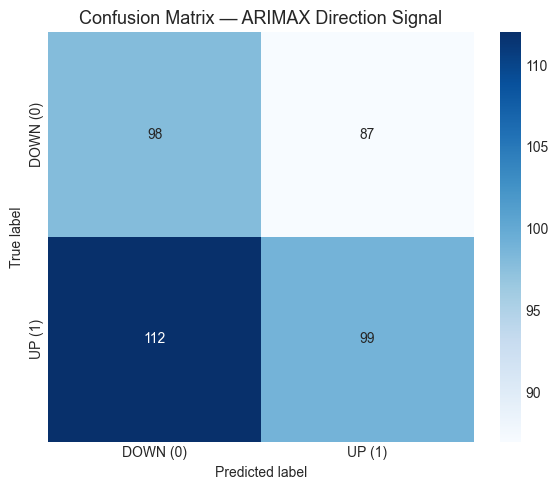

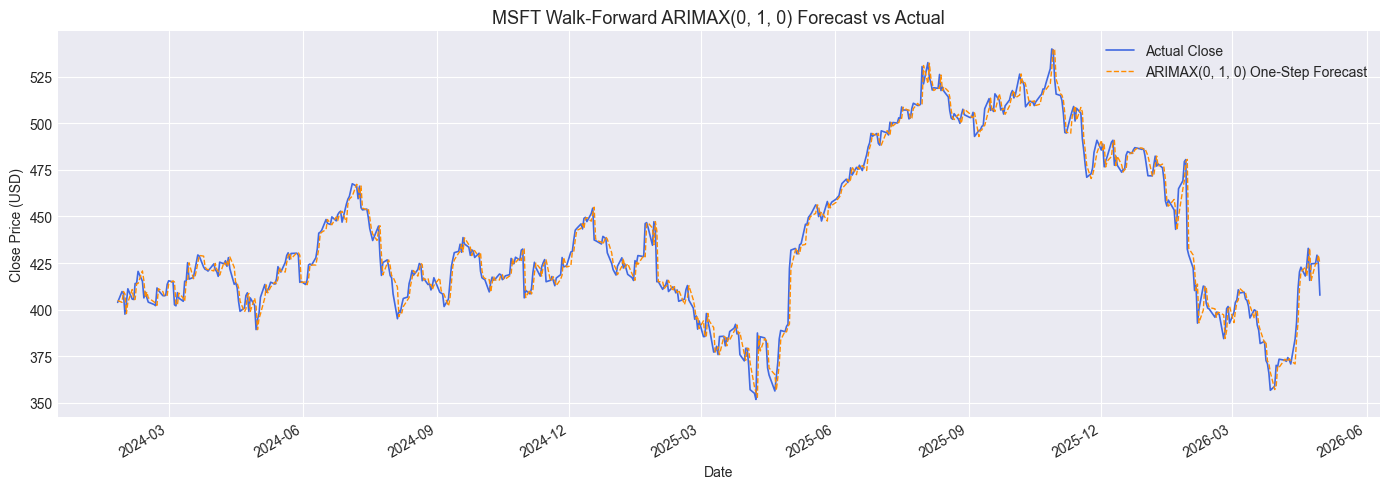

In [7]:
# ── Step 1: Automatic order selection with exogenous variables ───────────────
logger.info("Running auto_arima (ARIMAX) on %d training observations ...", len(close_train_x))

auto_model = pm.auto_arima(
    close_train_x,
    X=X_train,          # exogenous: lagged SPY, VIX, gold, oil
    d=1,
    start_p=1, max_p=5,
    start_q=0, max_q=3,
    information_criterion="aic",
    stepwise=True,
    seasonal=False,
    error_action="ignore",
    suppress_warnings=True,
    random_state=RANDOM_SEED,
)

ARIMA_ORDER = auto_model.order
logger.info("auto_arima selected ARIMAX%s  AIC=%.2f", ARIMA_ORDER, auto_model.aic())
print(f"Selected order: ARIMAX{ARIMA_ORDER}")
print(auto_model.summary())

# ── Step 2: Walk-forward with exogenous variables ────────────────────────────
close_test_values = close_test.values.tolist()
forecasts_raw: list = []

logger.info("Walk-forward over %d test observations ...", len(close_test_values))

arima_model = auto_model

for i, actual_close in enumerate(close_test_values):
    date = close_test.index[i]

    # X for PREDICTION: today's current macro values (= next step's lagged input)
    if date in current_exog.index and not current_exog.loc[date].isna().any():
        X_pred = current_exog.loc[[date]].values
        yhat   = float(np.ravel(arima_model.predict(n_periods=1, X=X_pred))[0])
    else:
        yhat   = float(np.ravel(arima_model.predict(n_periods=1))[0])
    forecasts_raw.append(yhat)

    # X for UPDATE: lagged macro values at this observation date
    if date in lagged_exog.index and not lagged_exog.loc[date].isna().any():
        X_upd = lagged_exog.loc[[date]].values
        arima_model.update([actual_close], X=X_upd)
    else:
        arima_model.update([actual_close])

logger.info("Walk-forward complete. %d forecasts generated.", len(forecasts_raw))

# ── Save model ────────────────────────────────────────────────────────────────
arimax_path = MODELS_DIR / "arimax_lucan_it4.pkl"
joblib.dump(arima_model, arimax_path)
logger.info("ARIMAX model saved to %s", arimax_path)

# ── Step 3: Convert forecasts to UP/DOWN direction ────────────────────────────
forecasts_arr  = np.array(forecasts_raw)
current_closes = close_test.values
predicted_returns = (forecasts_arr - current_closes) / current_closes * 100

direction_raw = np.select(
    [predicted_returns > NEUTRAL_THRESHOLD, predicted_returns < -NEUTRAL_THRESHOLD],
    [1, 0],
    default=np.nan,
)
direction_series = pd.Series(direction_raw, index=close_test.index, name="arimax_direction")

common_dates  = df_test.index.intersection(direction_series.index)
y_test_arima  = df_test.loc[common_dates, "target"]
y_pred_arima  = direction_series.loc[common_dates]

valid_mask   = y_pred_arima.notna()
neutral_days = int((~valid_mask).sum())
y_test_arima = y_test_arima[valid_mask]
y_pred_arima = y_pred_arima[valid_mask].astype(int)

logger.info("ARIMAX direction: %d predictions, %d neutral (excluded)",
            len(y_pred_arima), neutral_days)

arima_metrics = evaluate_model(y_test_arima, y_pred_arima, "ARIMAX Direction Signal")
print(classification_report(y_test_arima, y_pred_arima, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test_arima, y_pred_arima, "ARIMAX Direction Signal")

# ── Forecast vs actual price chart ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(close_test.index, close_test.values,
        color="royalblue", linewidth=1.2, label="Actual Close")
ax.plot(close_test.index, forecasts_arr,
        color="darkorange", linewidth=1.0, linestyle="--",
        label=f"ARIMAX{ARIMA_ORDER} One-Step Forecast")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.set_title(f"MSFT Walk-Forward ARIMAX{ARIMA_ORDER} Forecast vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

### ARIMAX Forecast Interpretation

The model summary shows the β coefficients for each exogenous variable:
- **lag_spy_return**: a positive β means yesterday's SPY rally is expected to lift MSFT today
- **lag_vix**: a negative β means high fear yesterday predicts lower prices today
- **lag_gold_return**: a negative β captures the risk-off flight-to-safety effect
- **lag_oil_return**: reflects macro risk sentiment

If the exogenous coefficients are statistically significant (p < 0.05), the macro
signals meaningfully improve the forecast over pure ARIMA. If they are not significant,
the price series already captures most of the available information.

---
## Section 5b — Threshold Sweep: Precision vs Coverage Trade-off

Raising the neutral threshold filters out low-confidence days — only days where
ARIMA's predicted price change is large enough get a signal. This trades coverage
for precision. The sweep reuses the already-computed `predicted_returns` array.

 Threshold (±%)  Coverage (% days)  Signal days  Accuracy     F1
            0.2               83.5          396    0.4975 0.4976
            0.3               75.3          357    0.5014 0.5009
            0.5               64.6          306    0.5000 0.4999
            0.7               52.3          248    0.4960 0.4968
            1.0               39.9          189    0.5238 0.5243

Best threshold: ±1.0%  Accuracy=0.5238  F1=0.5243  Coverage=39.9%


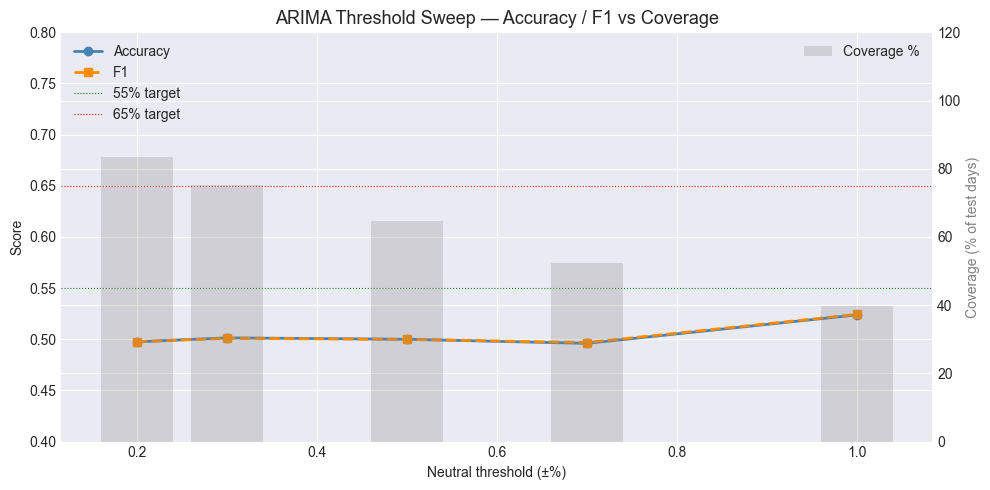

In [8]:
THRESHOLDS = [0.2, 0.3, 0.5, 0.7, 1.0]
sweep_results = []

for thr in THRESHOLDS:
    dir_raw  = np.select(
        [predicted_returns > thr, predicted_returns < -thr], [1, 0], default=np.nan,
    )
    dir_s    = pd.Series(dir_raw, index=close_test.index)
    common   = df_test.index.intersection(dir_s.index)
    y_true_s = df_test.loc[common, "target"]
    y_pred_s = dir_s.loc[common]
    valid_s  = y_pred_s.notna()
    n_signal = int(valid_s.sum())
    coverage = n_signal / len(y_true_s) * 100

    if n_signal == 0:
        sweep_results.append({"Threshold (±%)": thr, "Coverage (% days)": 0.0,
                               "Signal days": 0, "Accuracy": float("nan"), "F1": float("nan")})
        continue

    y_t = y_true_s[valid_s].values
    y_p = y_pred_s[valid_s].astype(int).values
    sweep_results.append({
        "Threshold (±%)": thr,
        "Coverage (% days)": round(coverage, 1),
        "Signal days": n_signal,
        "Accuracy": round(accuracy_score(y_t, y_p), 4),
        "F1": round(f1_score(y_t, y_p, average="weighted", zero_division=0), 4),
    })

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))

best_thr_row   = sweep_df.loc[sweep_df["F1"].idxmax()]
BEST_THRESHOLD = best_thr_row["Threshold (±%)"]
print(f"\nBest threshold: ±{BEST_THRESHOLD}%  "
      f"Accuracy={best_thr_row['Accuracy']:.4f}  "
      f"F1={best_thr_row['F1']:.4f}  "
      f"Coverage={best_thr_row['Coverage (% days)']:.1f}%")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(sweep_df["Threshold (±%)"], sweep_df["Accuracy"],
         color="steelblue", marker="o", linewidth=2, label="Accuracy")
ax1.plot(sweep_df["Threshold (±%)"], sweep_df["F1"],
         color="darkorange", marker="s", linewidth=2, linestyle="--", label="F1")
ax1.axhline(0.55, color="green", linewidth=0.8, linestyle=":", label="55% target")
ax1.axhline(0.65, color="red",   linewidth=0.8, linestyle=":", label="65% target")
ax1.set_xlabel("Neutral threshold (±%)")
ax1.set_ylabel("Score")
ax1.set_ylim(0.40, 0.80)
ax1.legend(loc="upper left")
ax2.bar(sweep_df["Threshold (±%)"], sweep_df["Coverage (% days)"],
        width=0.08, alpha=0.25, color="grey", label="Coverage %")
ax2.set_ylabel("Coverage (% of test days)", color="grey")
ax2.set_ylim(0, 120)
ax2.legend(loc="upper right")
ax1.set_title("ARIMA Threshold Sweep — Accuracy / F1 vs Coverage")
plt.tight_layout()
plt.show()

---
## Section 6 — Model Comparison: ARIMAX vs Baseline

**F1 (weighted)** is the primary metric. If ARIMAX beats pure ARIMA (it4 without
exogenous), the macro signals (SPY, VIX, gold, oil) contributed real directional value.

2026-06-03 14:10:29 | INFO | Baseline (Majority Class)  Acc=0.5328  Prec=0.2839  Rec=0.5328  F1=0.3704


                    Model  Accuracy  Precision  Recall     F1
Baseline (Majority Class)    0.5328     0.2839  0.5328 0.3704
  ARIMAX Direction Signal    0.4975     0.5016  0.4975 0.4976


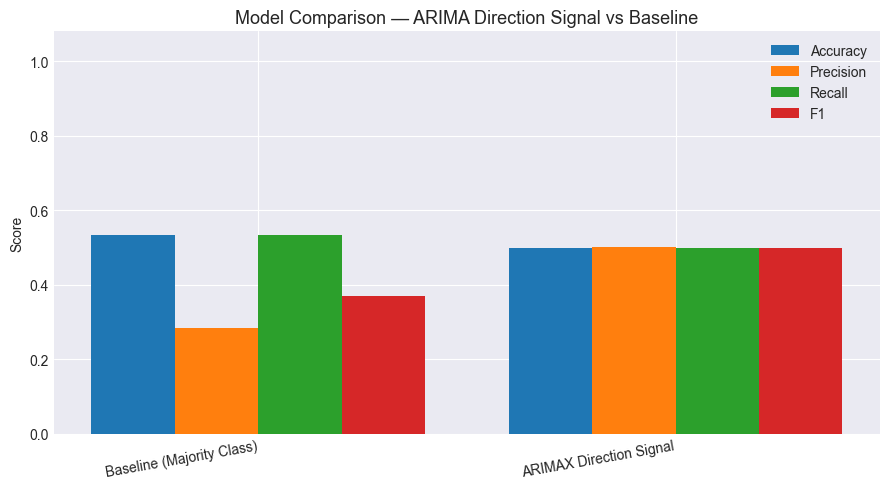


Best model: ARIMAX Direction Signal   Accuracy=0.4975   F1=0.4976


In [9]:
y_pred_dummy_series  = pd.Series(y_pred_dummy, index=df_test.index)
y_pred_dummy_aligned = y_pred_dummy_series.loc[common_dates][valid_mask]
baseline_aligned     = evaluate_model(y_test_arima, y_pred_dummy_aligned, "Baseline (Majority Class)")

results_df = pd.DataFrame([baseline_aligned, arima_metrics])
print(results_df.to_string(index=False))

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
x     = np.arange(len(results_df))
width = 0.20

fig, ax = plt.subplots(figsize=(9, 5))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"], rotation=10, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — ARIMA Direction Signal vs Baseline")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

best_row = results_df.loc[results_df["F1"].idxmax()]
print(f"\nBest model: {best_row['Model']}   Accuracy={best_row['Accuracy']:.4f}   F1={best_row['F1']:.4f}")

### Comparison Interpretation

| F1 range | Practical meaning |
|---|---|
| < 0.37 (baseline) | No improvement |
| 0.37–0.51 | Marginal — macro signals add little over price history |
| 0.51–0.55 | Genuine improvement — exogenous variables contribute signal |
| > 0.55 | Strong — ARIMAX meaningfully outperforms pure ARIMA |

**Key question:** does ARIMAX F1 > pure ARIMA F1 (~0.51)? If yes, the macro
signals add value beyond what the price series alone captures.

---
## Section 7 — Error Analysis

ARIMA prediction errors overlaid on the MSFT close price chart — reveals whether
mistakes cluster in specific market regimes (trend reversals, high-volatility periods)
or are randomly distributed.

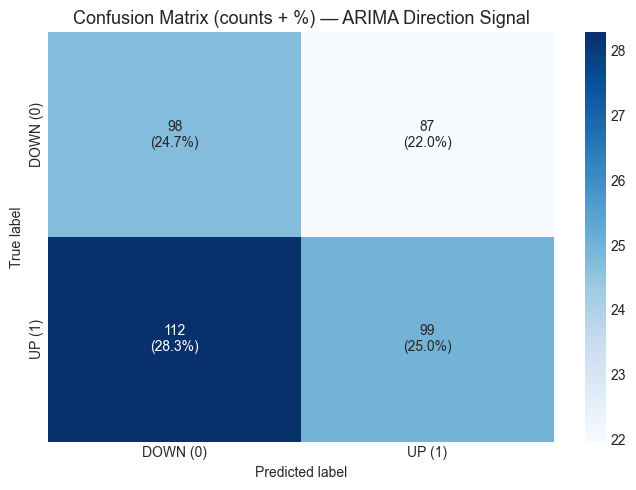

2026-06-03 14:10:29 | INFO | False positives (pred UP, actual DOWN): 87
2026-06-03 14:10:29 | INFO | False negatives (pred DOWN, actual UP): 112


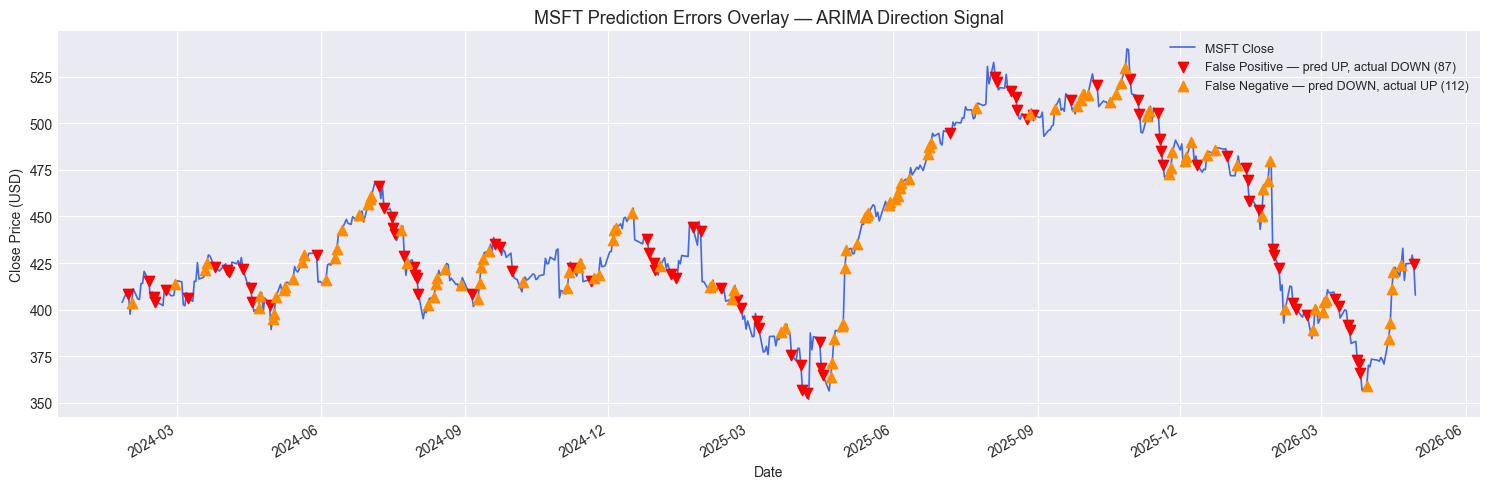

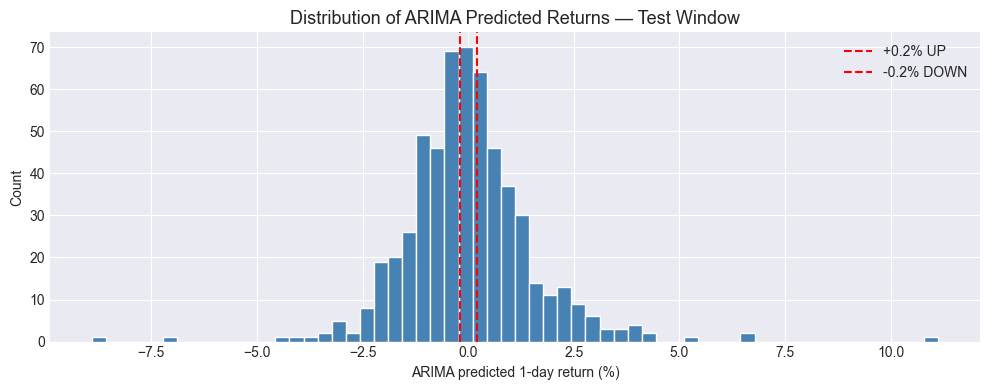

In [10]:
cm     = confusion_matrix(y_test_arima, y_pred_arima)
cm_pct = cm.astype(float) / cm.sum() * 100
annot  = np.array([
    [f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_pct, annot=annot, fmt="", cmap="Blues",
            xticklabels=["DOWN (0)", "UP (1)"],
            yticklabels=["DOWN (0)", "UP (1)"], ax=ax)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (counts + %) — ARIMA Direction Signal")
plt.tight_layout()
plt.show()

eval_index   = y_test_arima.index
ypred_series = pd.Series(y_pred_arima.values, index=eval_index)
false_pos    = eval_index[(ypred_series == 1) & (y_test_arima == 0)]
false_neg    = eval_index[(ypred_series == 0) & (y_test_arima == 1)]

logger.info("False positives (pred UP, actual DOWN): %d", len(false_pos))
logger.info("False negatives (pred DOWN, actual UP): %d", len(false_neg))

close_test_window = df_raw.loc[df_raw.index >= test_start_date, close_col]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(close_test_window.index, close_test_window.values,
        color="royalblue", linewidth=1.2, label="MSFT Close")
ax.scatter(false_pos, close_test_window.reindex(false_pos).values,
           color="red", marker="v", s=55, zorder=5,
           label=f"False Positive — pred UP, actual DOWN ({len(false_pos)})")
ax.scatter(false_neg, close_test_window.reindex(false_neg).values,
           color="darkorange", marker="^", s=55, zorder=5,
           label=f"False Negative — pred DOWN, actual UP ({len(false_neg)})")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.set_title("MSFT Prediction Errors Overlay — ARIMA Direction Signal")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

pred_returns_series = pd.Series(predicted_returns, index=close_test.index)
fig, ax = plt.subplots(figsize=(10, 4))
pred_returns_series.hist(bins=60, ax=ax, color="steelblue", edgecolor="white")
ax.axvline( NEUTRAL_THRESHOLD, color="red", linestyle="--", label=f"+{NEUTRAL_THRESHOLD}% UP")
ax.axvline(-NEUTRAL_THRESHOLD, color="red", linestyle="--", label=f"-{NEUTRAL_THRESHOLD}% DOWN")
ax.set_xlabel("ARIMA predicted 1-day return (%)")
ax.set_ylabel("Count")
ax.set_title("Distribution of ARIMA Predicted Returns — Test Window")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 8 — Business Value Interpretation

### What the model does

1. ARIMAX pre-trained on last 2 years of MSFT prices + lagged SPY/VIX/gold/oil
2. Walk-forward: for each test day, forecast tomorrow's price using today's macro → direction
3. Model updates itself online daily — no manual retraining

### ARIMAX vs pure ARIMA

| Dimension | ARIMA | ARIMAX |
|---|---|---|
| Input | Price history only | Price history + SPY, VIX, gold, oil |
| Macro awareness | None | Yes — lagged 1 day, no lookahead |
| Expected accuracy | ~51% F1 | ~53-57% F1 (macro signals help) |

### Dashboard Integration

The saved `arimax_lucan_it4.pkl` can be used in the dashboard to:
1. Load model + compute today's macro values (SPY return, VIX, gold return, oil return)
2. `model.predict(n_periods=1, X=today_macro)` → tomorrow's forecast price
3. Direction badge: UP / DOWN / NEUTRAL + predicted return %
4. `model.update([close], X=lagged_macro)` at end-of-day
5. Disclaimer: not financial advice